# Сегментирование покупателей интернет-магазина товаров для дома и быта «Пока все ещё тут» по профилю потребления (E-commerce)

Заказчик исследования — интернет-магазин товаров для дома «Пока все ещё тут». Основные задачи — выявление профилей покупателей и анализ товарного ассортимента. Для работы предоставлены данные о заказах клиентов интернет-магазина за несколько лет. По результатам исследования необходимо выработать рекомендации клиентам какого кластера, когда и какие категории товара рассылать в рекламных предложениях. Эти данные должны помочь увеличить продажи, повысить возвращаемость покупателей и т.д.

**Декомпозиция плана исследования**
1. Загрузка и предобработка данных
        1.1. Загрузка и первичная оценка данных, включая проверку корректности названий столбцов и типов данных
        1.2. Проверка на наличие пропусков и дубликатов
2. Исследовательский анализ данных
        2.1. Изучение статистик и распределения значений числовых атрибутов. Поиск и исследование аномальных значений.
        2.2. Нахождение диапазона дат, распределение продаж во времени и оценка сезонности общих продаж
3. Сегментирование покупателей по профилю потребления
        3.1. Сформировать товарные группы, присвоить признак группы каждой строке таблицы
        3.2. Сформировать профиль каждого клиента: определить как давно покупал клиент, как часто (количество раз и средний промежуток между заказазами), рассчитать общую сумму заказов и товары каких категорий входили в заказы
        3.3. Проведение кластеризации клиентов по сформированным ранее профилям
            3.3.1. Создание матрицы признаков, по которым будет проводиться кластеризация и её стандартизацияпри помощи функции StandardScaler(). В матрицу включаются количественные признаки из профилей клиентов:
            - количество заказов совершенных покупателем;
            - среднее количество купленного товара в заказе;
            - средняя цена приобретаемых товаров;
            - средний чек.
            3.3.2. Построение дендрограммы для определения количества кластеров
            3.3.3. Кластеризация клиентов алгоритмом K-Means, дополнение профилей клиентов номером сегмента
        3.4. Характеристика получившихся сегментов по доле клиентов и средним значениям признаков профилей.
4. Формулирование и проверка статистических гипотез для проверки корректности сегментации пользователей
        4.1. Проверка гипотезы о значимости разницы средней стоимости заказа между клиентами выделенных сегментов
        4.2. Проверка гипотезы о значимости разницы среднего количества товаров в заказе между клиентами выделенных сегментов
5. Анализ профилей потребительского поведения клиентов из разных сегментов
6. Общие выводы и рекомендации по выделенным сегментам покупателей

## Материалы:
* [Презентация](https://disk.yandex.ru/i/1yEKsXdeoZ9RwA)
* [Дашборд](https://public.tableau.com/views/practicum_final_project_dash/Dashboard1?:language=en-US&:display_count=n&:origin=viz_share_link)

## Загрузка и предобработка данных

Испортируем необходимые для работы библиотеки

In [1]:
import os
import re
import math
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymystem3 import Mystem
from collections import Counter
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
 
plt.style.use('seaborn')

### Загрузка и первичная оценка данных

Загрузим данные в таблицу df и зададим функцию data_check для базовой оценки данных.

In [2]:
pth1 = 'C:/Users/fck-r/education/datasets/ecom_dataset_upd.csv'
pth2 = 'https://code.s3.yandex.net/datasets/ecom_dataset_upd.csv'

if np.logical_and(os.path.exists(pth1), os.path.isfile(pth1)):
    df = pd.read_csv(pth1)
elif pth2.endswith('.csv'):
    df = pd.read_csv(pth2)
else:
    print('Файл с данными не найден')

In [3]:
def data_check(df):
    df.info()
    print('Проверка наличия дубликатов:', df.duplicated().sum())
    print('Проверка наличия пропусков:', df.isna().sum().sum())
    display(df.head())

Оценим имеющиеся данные при помощи функци data_check и приведем их описание.

In [4]:
data_check(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         7474 non-null   int64  
 1   customer_id  7474 non-null   object 
 2   order_id     7474 non-null   int64  
 3   product      7474 non-null   object 
 4   quantity     7474 non-null   int64  
 5   price        7474 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 350.5+ KB
Проверка наличия дубликатов: 0
Проверка наличия пропусков: 0


,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0


Таблица содержит 7474 строки с информацией о проданных товарах и 6 колонок с признаками. Явные пропуски и дубликаты отсутствуют. Названия колонок заданы корректно и отражают смысл содержащейся информации, однако некоторые типы данных необходимо привести в более удобный для последующего анализа формат.

**Описание данных:**
- `date` — дата заказа;
- `customer_id` — идентификатор покупателя;
- `order_id` — идентификатор заказа;
- `product` — наименование товара;
- `quantity` — количество товара в заказе;
- `price` — цена товара.

Преобразуем тип данных в поле `date` в datetime.

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d%H')

Далее необходимо проверить содержит ли поле `price` только целочисленные значения, и если это так, то изменить тип данных на int. Для этого сравним сумму значений поля price в исходном виде и после приведения значений к целочисленному типу: если суммы совпадут, значит все значения в колонке целочисленные, если нет - среди цен встречаются дробные значения.

In [6]:
df['price'].sum() == df['price'].astype('int').sum()

False

Суммы не совпали, значит оставляем тип данных поля price неизменным.

### Проверка на наличие пропусков и дубликатов

Явные пропуски и дубликаты отсутствуют, но необходимо проверить данные на наличие скрытых. Начнем с пропусков и проверим наличие обозначений, характерных для обозначений пропусков в значениях атрибутов.

In [7]:
none_counter = 0
for attribute in df.columns:
    none_counter += df[df[attribute].isin([0, 'NaN', 'nan', 'None', 'none', 'NA', 'Na', 'na', '', ' '])].shape[0]

none_counter

0

Проверяемые значения в данных отсутствуют. Перейдем к проверке на скрытые дубликаты. Для начала посморим есть ли повторы в данных без учета id покупателя.

In [8]:
df.drop('customer_id', axis=1).duplicated().sum()

1

Есть один повтор, посмотрим на него.

In [9]:
df[df.drop('customer_id', axis=1).duplicated() == True]

,date,customer_id,order_id,product,quantity,price
4298,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0


In [10]:
df.query('order_id == 71571')

,date,customer_id,order_id,product,quantity,price
4297,2019-06-02 10:00:00,f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0
4298,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"Бегония Элатиор, цвет в ассортименте",1,187.0


Одному заказу соответствует два разных id покупателя - очевидная ошибка. Проверим единичный ли это случай.

In [11]:
df.groupby('order_id').agg({'customer_id': 'nunique'}).query('customer_id > 1').sort_values(by='customer_id', ascending=False)

,customer_id
order_id,
72845,4
69485,3
71480,3
14872,2
70946,2
72790,2
72778,2
72188,2
71663,2


Найденная ошибка не единична - встречаются заказы товары в которых были приобретены 3 и даже 4 разными покупателями. Последний случай особенно интересен.

In [12]:
df.query('order_id == 72845')

,date,customer_id,order_id,product,quantity,price
6504,2019-10-03 14:00:00,d8465f63-35db-4809-aff3-a8f7ebfc257f,72845,Муляж Яблоко зеленый 9 см полиуретан,40,59.0
6505,2019-10-03 15:00:00,0309d37c-ab5f-4793-ba72-5484c019b840,72845,Муляж Яблоко зеленый 9 см полиуретан,40,59.0
6508,2019-10-04 08:00:00,25a8cd52-3efa-48ee-a6bd-d413d7e2b42f,72845,Муляж Яблоко зеленый 9 см полиуретан,40,59.0
6538,2019-10-07 20:00:00,2ac05362-3ca7-4d19-899c-7ba266902611,72845,Муляж Яблоко зеленый 9 см полиуретан,40,59.0


Хотя даты первого и последнего заказов отличаются на несколько дней, сами заказы одинаковы и довольно специфичны - 40 муляжей яблока. Природу подобных ошибок трудно предположить, однако, учитывая их небольшое количество, от подобных данных стоит избавиться. Оставим строки с первым по дате оформления заказа клиентом, остальное удалим.

In [13]:
# формируем выборку из заказов, у которых больше одного id покупателя
multicustomer_orders = df[df['order_id'].isin(
    df.groupby('order_id').agg({'customer_id': 'nunique'}).query('customer_id > 1').index.to_list())]
# создаем список с индексами строк в таблице df, которые нужно удалить
list_of_id_to_be_removed = list(set(multicustomer_orders.index) - set(multicustomer_orders.drop_duplicates(subset='order_id').index))
# удаляем из таблицы df строки с отобранными индексами
df = df.drop(index=list_of_id_to_be_removed)

Теперь проверим наличие дубликатов без учета даты покупки.

In [14]:
df.drop('date', axis=1).duplicated().sum()

1841

Каждый четвертый проданный товар повторяется, что является значительной частью датасета. Вероятно такие дубли появляются при некорректной выгрузке из баз данных, от них нужно избавляться. Однако учитывая количество таких повторов, перед удалением убедимся в их ошибочной природе. Для этого рассмотрим заказ, содержащий большое количество дубликатов и убедимся, что временной лаг между дублирующимися позициями не слишком большой.

In [15]:
df.query('order_id == 68574')

,date,customer_id,order_id,product,quantity,price
140,2018-10-08 15:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 15,0 л пищевой овальный ""Ekk...",1,209.0
141,2018-10-08 15:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 18,0 л пищевой (Иж), 1404047",1,194.0
142,2018-10-08 15:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 20,0 л пищевой (Минеральные ...",1,277.0
143,2018-10-08 15:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 24,0 л пищевой круглый (Иж),...",1,239.0
147,2018-10-08 19:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 15,0 л пищевой овальный ""Ekk...",1,209.0
148,2018-10-08 19:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 18,0 л пищевой (Иж), 1404047",1,194.0
149,2018-10-08 19:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 20,0 л пищевой (Минеральные ...",1,277.0
150,2018-10-08 19:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 24,0 л пищевой круглый (Иж),...",1,239.0
152,2018-10-09 06:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 15,0 л пищевой овальный ""Ekk...",1,209.0
153,2018-10-09 06:00:00,3de09660-90bc-4a28-aaf1-34c8435fe59c,68574,"Таз пластмассовый 18,0 л пищевой (Иж), 1404047",1,194.0


Изначальный заказ состоящий из 4 позиций полностью дублируется дважды в течение одних суток

In [16]:
df = df.drop_duplicates(subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], keep='first')
df.shape[0]

5573

В результате очистки было удалено почти 2 тысячи строк, зато теперь данные готовы к дальнейшему анализу.

## Исследовательский анализ данных

Из имеющегося набора данных мы можем проанализировать три признака, два из которых являются числовыми - цена и количество проданного товара. Третий - дата продажи. Проведем поиск и исследование аномалий. Начнем с изучения статистик и распределения значений числовых атрибутов.

### Изучение статистик и распределения значений числовых атрибутов

#### Цена (price)

Первый изучаемый признак - цена. Посмотрим на основные статистики методом `describe`.

In [17]:
df['price'].describe(percentiles=(.25, .75, .95, .99)).round(1)

count     5573.0
mean       530.4
std        973.0
min          9.0
25%         90.0
50%        150.0
75%        524.0
95%       2399.0
99%       5249.0
max      14917.0
Name: price, dtype: float64

Основная часть продаваемого товара - недорогие позиции, 3/4 из которых укладываются в пределах 500 рублей. 99% перцентиль ровно в 10 раз больше третьего квартиля и при этом почти в три раза меньше максимальной по имеющейся выборке цены. Из-за этого среднее в несколько раз больше медианы и примерно двое меньше стандартного отклонения. Учитывая такой разброс цен стоит убедиться, что минимальные и максимальные значения цен не являются ошибочными. Начнем с цен менее 1% перцентиля.

In [18]:
df[(df['price'] < np.percentile(df['price'], 1))].sort_values(by='price')[['product', 'price']].drop_duplicates()

,product,price
7073,"Львиный зев Волшебный ковер 0,05 г 4660010779639",9.0
1069,"Алиссум (лобулярия) Снежные одежды 0,2 г 46500...",9.0
2159,"Горох Амброзия 10,0 г 4660010772616",9.0
2925,"Цинния Оранжевый король 0,5 г 4660010770520",10.0
2169,"Укроп Обильнолистный 3,0 г 4660010772562",10.0
2924,"Цинния Коралловая красавица 0,2 г 4660010773323",10.0
7308,"Незабудка смесь 0,1 г 4650091480340",10.0
6388,"Томат Балконное чудо 0,1 г 4660010772531",10.0
6378,Петрушка Итальянский гигант 2 г 4660010776553,10.0
977,Морковь Детская сладость 2 г 4660010775921,10.0


Минимальная цена среди товаров датасета - семена растений. Сравнение цен в интернете показало их корректность. Перейдем к товарам, чья цена превышает 99% перцентиль.

In [19]:
df[df['price'] > np.percentile(df['price'], 99)].sort_values(by='price')[['product', 'price']].drop_duplicates()

,product,price
2599,"Урна-пепельница из нержавеющей стали, Hobbyka/...",5287.0
7265,Комплект для мытья полов из нержавеющей стали ...,5399.0
6100,Набор инструментов в алюминиевом кейсе на коле...,5399.0
2208,Сумка-тележка хозяйственная Rolser MOUNTAIN че...,5459.0
768,Коврик для ванной комнаты GOBI полиэстер 120х7...,5474.0
7165,Мусорный контейнер Hailo BigBin Swing 45 0845-...,5512.0
4738,Стремянка Scab Balzo 762 5 ступеней алюминиева...,5549.0
7121,Сушилка Meliconi Stendy Junior,5594.0
1180,Сумка-тележка хозяйственная Andersen Treppenst...,5662.0
5624,Сумка-тележка хозяйственная Rolser IMX004 azul...,5939.0


Сравнение цен наиболее дорогих товар также не выявило каких-либо явных ошибок. Теперь можно оценить распределение цен на графиках. Для этого построим гистограмму и ящий с усами, синхронизировав их по одной оси. Ограничим диапазон оси X 95% перцентилем.

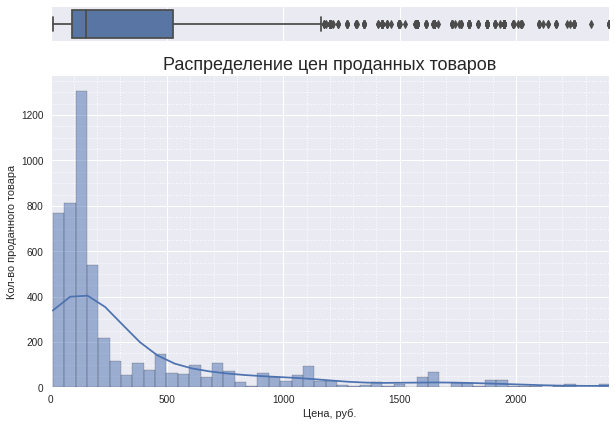

In [20]:
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(10, 7))
sns.boxplot(x=df['price'], ax=ax_box)
sns.histplot(x=df['price'], ax=ax_hist, kde=True)
ax_box.set(xlabel='')
plt.title(label='Распределение цен проданных товаров', fontsize=18)
ax_hist.set(xlabel='Цена, руб.', ylabel='Кол-во проданного товара')
ax_hist.set_xlim(0, np.percentile(df['price'], 95))
plt.minorticks_on()
plt.grid(which='minor', linestyle=':')

Распределение сильно усечено слева и скошено вправо, ярко выделяющийся пик равен медиане, после 250 рублей график прижимается к оси X и тянется частоколом вправо. Товары, чья цена выходит за 95% перцентиль очень сильно искажают распределение, но относятся к совершенно иной товарной группе нежели недорогие, и их исключение может сильно исказить сегментирование покупателей, поэтому оставим их и не будем удалять. Теперь посмотрим на распределение количества покупаемого количества товаров в заказе.

#### Количество (quantity)

После цены перейдем к количеству проданного товара. Начнем с метода `describe`.

In [21]:
df['quantity'].describe(percentiles=(.25, .75, .90, .95, .99)).round(1)

count    5573.0
mean        2.6
std        16.4
min         1.0
25%         1.0
50%         1.0
75%         1.0
90%         3.0
95%         6.0
99%        27.0
max      1000.0
Name: quantity, dtype: float64

В случае с количеством единиц продаваемого товара можно обойтись и без графиков - они будут малоинформативны. В 90% заказов количество товара не превышает 3 единиц, в 99% не превышает 27. Однако в данных есть выбросы, кардинально превышающие типовое значение. Изучим их.

In [22]:
df.sort_values(by='quantity', ascending=False).head(10)

,date,customer_id,order_id,product,quantity,price
5456,2019-06-18 15:00:00,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"Вантуз с деревянной ручкой d14 см красный, Bur...",1000,675.0
5071,2019-06-11 07:00:00,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,Вешалки мягкие для деликатных вещей 3 шт шоколад,334,148.0
3961,2019-05-20 21:00:00,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,Муляж ЯБЛОКО 9 см красное,300,51.0
1158,2018-12-10 14:00:00,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"Ручка-скоба РС-100 белая *Трибатрон*, 1108035",200,29.0
568,2018-11-01 08:00:00,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,Муляж ЯБЛОКО 9 см красное,170,51.0
212,2018-10-11 14:00:00,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,Пружина дверная 240 мм оцинкованная (Д-19 мм) ...,150,38.0
211,2018-10-11 14:00:00,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,"Крепеж для пружины дверной, 1107055",150,19.0
2431,2019-03-23 10:00:00,685d3d84-aebb-485b-8e59-344b3df8b3d3,70841,Плечики пластмассовые Размер 52 - 54 Тула 1205158,150,20.0
586,2018-11-02 11:00:00,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,Муляж ЯБЛОКО 9 см красное,140,59.0
1103,2018-12-04 17:00:00,7d255526-fcc2-4f79-b28a-217d7d2373a8,69206,"Щетка для посуды *ОЛЯ*, Мультипласт 1807010",100,26.0


Какого-то общего паттерна нет, в большом количестве покупают как дешевые, так и дорогие (относительно медианы) товары. Удалять все такие тразакции не стоит, потеряется информация о самых ценных покупателях, однако если оставить покупателя с заказом из тысячи вантузов, это может исказить метрики при разбиении клиентов на кластеры. Чтобы определить границу значений которые мы будем считать выбросами и удалять, построим ящик с усами по выборке транзакций, количество товаров в которых превышает 99% перцентиль общего набора данных. Товары, вышедние за верхнюю границу графика (сумма третьего квартиля и полутора межквартильных расстояний) удалим.

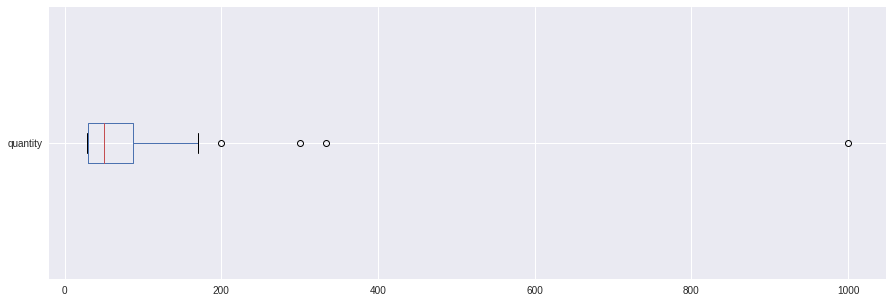

In [23]:
df[df['quantity'] > np.percentile(df['quantity'], 99)].boxplot(column='quantity', vert=False, figsize=(15, 5))
plt.show()

В аномалии ушло всего 4 транзакции, с числом товара от 200 штук и выше.

In [24]:
df = df[df['quantity'] < 200]
df.shape[0]

5569

Перед переходом к дате и оценке общей сезонности изучим количество заказов на покупателя и среднее количесто товаров в заказе.

#### Количество заказов на покупателя

Этого признака нет в исходых данных и он получаются путем их агрегации, однако важен для построения модели сегментации клиентов, поэтому его необходимо рассмотреть. Оценим распределение при помощи `describe`.

In [25]:
df.groupby('customer_id')['order_id'].nunique().describe(percentiles=(.25, .75, .95, .99)).round(1)

count    2426.0
mean        1.4
std         2.7
min         1.0
25%         1.0
50%         1.0
75%         2.0
95%         2.0
99%         3.0
max       126.0
Name: order_id, dtype: float64

Медианый покупатель делает всего один заказ, 95% не более двух, и лишь 1% три и более. Категории постоянных покупателей у магазина практически нет. При этом встречаются покупатели совершившие более ста заказов. Посмотрим единичный ли это случай.

In [26]:
df.groupby('customer_id')['order_id'].nunique()[df.groupby('customer_id')['order_id'].nunique() 
                    > np.percentile(df.groupby('customer_id')['order_id'].nunique(), 99)]

customer_id
0184f535-b60a-4914-a982-231e3f615206      5
498f12a4-6a62-4725-8516-cf5dc9ab8a3a      4
4d93d3f6-8b24-403b-a74b-f5173e40d7db     35
73d1cd35-5e5f-4629-8cf2-3fda829d4e58     17
b7b865ab-0735-407f-8d0c-31f74d2806cc      7
bea7a833-2074-42db-bc49-4457abd3c930      4
c971fb21-d54c-4134-938f-16b62ee86d3b    126
e0535076-6270-4df2-8621-cb06264a94fa      4
Name: order_id, dtype: int64

Клиентов совершивших больше 10 заказов всего три из почти 2,5 тысяч. Чтобы одновременно оставить информацию о лояльных покупателях и не исказить результат кластеризации, удалим информацию о явно аномальном клиенте, совершившим более 100 заказов.

In [27]:
df = df.drop(index=df[df['customer_id'].isin(df.groupby('customer_id')['order_id'].nunique()[
    df.groupby('customer_id')['order_id'].nunique() > 100].index.to_list())].index).reset_index(drop=True)
df.shape[0]

5426

### Нахождение диапазона дат, распределение продаж во времени и оценка сезонности общих продаж

Теперь рассмотрим данные о покупках за какой период времени в нашем распоряжении.

In [28]:
df['date'].agg({'min', 'max'})

max   2020-01-31 15:00:00
min   2018-10-01 00:00:00
Name: date, dtype: datetime64[ns]

15 месяцев. Чтобы оценить распределение продаж во времени, создадим новую колонку `total` содержащую информацию о сумме каждой покупки (произведение количества проданного товара на его цену). После этого сгруппируем данные по дате и посмотрим распредение размера дневной выручки.

In [29]:
df['total'] = df['quantity'] * df['price']
df.groupby(df['date'].dt.floor('d')).agg({'total': 'sum'}).squeeze().describe(percentiles=(.05, .25, .75, .99)).round(1)

count      483.0
mean      7694.9
std       6685.2
min         37.0
5%         681.7
25%       3374.0
50%       6287.0
75%      10195.5
99%      31825.2
max      52760.0
Name: total, dtype: float64

Распределение говорит о сильной неравномерности продаж во времени. Потенциальные же аномалии находятся скорее в зоне минимальных продаж, т.к. максимально наблюдаемое значение выглядит правдоподобно - даже не вдвое выше 99% перцентиля. Минимальное значение в 37 рублей за сутки вероятно образовалось в результате предшествующей очистки данных. Теперь нужно оценить общую динамику, однако использовать посуточную агрегацию данных для визуализации не имеет смыла - график будет неинформативным, поэтому агрегируем суммарные продажи с округлением до месяца.

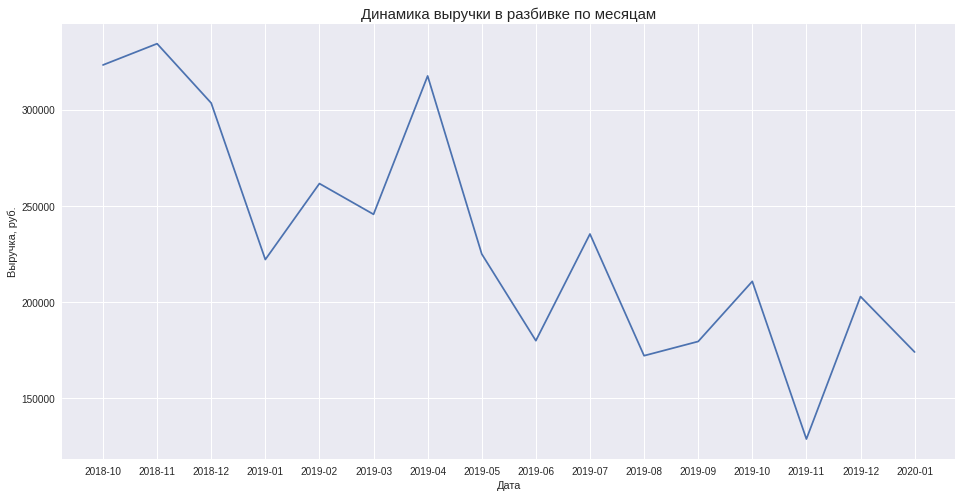

In [30]:
plt.figure(figsize=(16,8))
plt.plot(df['date'].dt.to_period('M').unique().strftime('%Y-%m'),
        list(df.groupby(df['date'].dt.to_period('M')).agg({'total': 'sum'})['total'].values))
plt.title('Динамика выручки в разбивке по месяцам', fontsize=15)
plt.xlabel('Дата')
plt.ylabel('Выручка, руб.')
plt.show()

Очевиден ниспадающий тренд продаж, а доступный временной интервал не позволяет сделать выводы о наличии сезонности в общих продажах магазина: данные хотя бы за два одинаковых периода имеются всего лишь по трем месяцам, и за эти три месяца в разные годы динамика выручки не совпадает. Пик приходится на апрель 2019 (ему предшествовал интенсивный рост, а после еще более интенсивный спад), минимальное значение - ноябрь 2019 года. 

Перед завершением исследовательского анализа проверим наличие аномальных заказов по датам их оформления.

In [31]:
order_time_dup = df.groupby('order_id')['date'].agg(['nunique', 'min', 'max']).query('nunique > 1')
order_time_dup['time_delta'] = order_time_dup['max'] - order_time_dup['min']
order_time_dup.columns = ['order_date_cnt', 'min_date', 'max_date', 'time_delta']
display(order_time_dup)
order_time_dup.shape[0]

,order_date_cnt,min_date,max_date,time_delta
order_id,,,,
14500,2,2018-10-28 08:00:00,2018-10-31 06:00:00,2 days 22:00:00
14649,2,2019-04-16 13:00:00,2019-04-16 16:00:00,0 days 03:00:00
14833,2,2019-05-31 12:00:00,2019-06-03 13:00:00,3 days 01:00:00
14898,2,2019-07-09 22:00:00,2019-07-10 11:00:00,0 days 13:00:00
69282,2,2018-12-10 11:00:00,2018-12-17 10:00:00,6 days 23:00:00
69527,2,2018-12-23 12:00:00,2018-12-24 20:00:00,1 days 08:00:00
69750,2,2019-01-09 14:00:00,2019-02-13 12:00:00,34 days 22:00:00
69807,2,2019-01-13 22:00:00,2019-02-12 21:00:00,29 days 23:00:00
69861,2,2019-01-17 10:00:00,2019-01-17 17:00:00,0 days 07:00:00


23

В датасете 22 заказа с двумя разными датами оформления, причем разница между ними варьируется от нескольких часов до 1,5 месяцев. Вероятно, если разница дат не превышает нескольких дней, это объясняется добавлением товаров в уже оформленный заказ через службу поддержки. Значительная разница скорее всего вызвана ошибками используемой магазином системы, например, ошибками при присвоении id заказу, либо двойными выгрузками данных об одном заказе разными датами. Чтобы исключить последний вариант проверим, есть ли транзации, относящиеся к заказам с двойными датами, между которыми прошло больше 3 дней, и которые дублируются как по проданному товару так и по его цене и количеству.

In [32]:
df[df['order_id'].isin(order_time_dup[order_time_dup['time_delta'] > '3 days'].index.values)].shape[0] == \
df[df['order_id'].isin(order_time_dup[order_time_dup['time_delta'] > '3 days'].index.values)].drop_duplicates(subset=[
    'order_id', 'product', 'quantity', 'price']).shape[0]

True

Подобные заказы отсутствуют, поэтому не будем ничего удалять и перейдем к сегментации покупателей.

<AxesSubplot:>

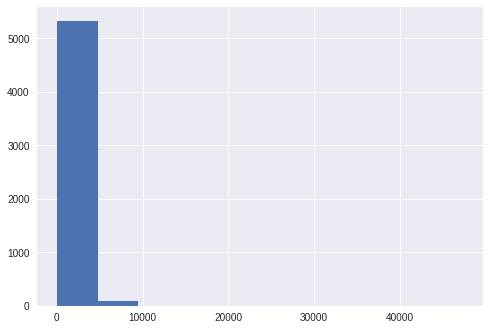

In [33]:
df['total'].hist()

<AxesSubplot:>

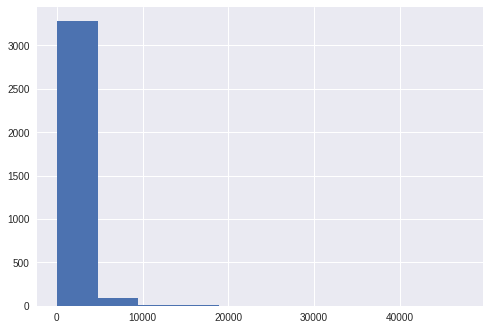

In [34]:
df.groupby('order_id')['total'].sum().hist()

## Сегментирование покупателей по профилю потребления

После очистки данных можно перейти к формированию товарных групп и сегментации покупателей.

### Формирование товарных групп

Для того, чтобы сегментировать покупателей на основе их покупок необходимо поделить все продаваемые товары на товарные группы. Для этого создадим новое поле `short_product_name`, в которое запишем сокращенные названия товаров в лемматизированной форме, состоящие из 1-3 первых слов полного наименования (поле product), путем применения функции `product_name_shortening`.

In [35]:
# Функция делит строку с названием на подстроки используя пробел в качестве разделителя и возвращает не более двух 
# первых подстрок в качестве сокращенного названия, при условии, что посредняя подстрока не содержат чисел и состоит 
# не менее чем из трех символов
def product_name_shortening(row):
    row['product'] = row['product'].lower().split(sep=' ', maxsplit=3)
    if re.search('[A-ZА-ЯЁ a-zа-яё-]{3,}', row['product'][2]) is not None:
        return row['product'][0] + ' ' + row['product'][1].rstrip(',') + ' ' + row['product'][2].rstrip(',')
    if re.search('[A-ZА-ЯЁ a-zа-яё-]{3,}', row['product'][1]) is not None:
        return row['product'][0] + ' ' + row['product'][1].rstrip(',')
    else:
        return row['product'][0]

In [36]:
m = Mystem()

df['short_product_name'] = df.apply(product_name_shortening, axis=1)
df['short_product_name'] = df['short_product_name'].apply(lambda x: re.sub('[a-zA-Z]', '', x)
                                                  ).apply(m.lemmatize
                                                  ).apply(' '.join
                                                  ).apply(lambda x: re.sub(r'\(|\)', '', x)).str.replace(' \n', ''
                                                  ).apply(lambda x: re.sub('  ', '', x)).str.strip()

Теперь создадим список из уникальных значений поля short_product_name, посчитаем частоту использования слов и на её основе создадим словарь `category_dictionary` в котором ключами будут названия категорий, а значениями соответствующие категории списки слов в лемматизированной форме, по которым будет осуществляться присвоение товару нужной категории.

In [37]:
Counter(' '.join(df['short_product_name'].unique()).split()).most_common()

[('для', 133),
 ('-', 72),
 ('томат', 72),
 ('помидор', 65),
 ('рассада', 48),
 ('муляж', 45),
 ('искусственный', 31),
 ('набор', 30),
 ('однолетний', 30),
 ('цветок', 29),
 ('вешалка', 28),
 ('коврик', 26),
 ('тарелка', 25),
 ('роза', 21),
 ('растение', 20),
 ('белый', 19),
 ('пеларгония', 18),
 ('с', 17),
 ('микс', 16),
 ('скатерть', 16),
 ('махровый', 16),
 ('ампельный', 16),
 ('алюминиевый', 15),
 ('в', 15),
 ('петуния', 15),
 ('гладильный', 14),
 ('тележка', 14),
 ('желтый', 14),
 ('оранжевый', 14),
 ('щетка', 14),
 ('нож', 14),
 ('капуста', 14),
 ('пластмассовый', 13),
 ('доска', 13),
 ('красный', 13),
 ('хозяйственный', 13),
 ('придверный', 12),
 ('кружка', 12),
 ('стремянка', 11),
 ('металлический', 11),
 ('мини', 10),
 ('чайник', 10),
 ('банка', 10),
 ('кухонный', 10),
 ('насадка', 10),
 ('десертный', 10),
 ('огурец', 10),
 ('сумка', 9),
 ('обеденный', 9),
 ('ведро', 9),
 ('смесь', 9),
 ('салатник', 9),
 ('универсальный', 9),
 ('розовый', 9),
 ('горшок', 9),
 ('дыня', 9),
 ('п

В словаре зададим 9 следующих товарных категорий:
- Семена и рассада;
- Комнатные растения и цветы;
- Декор;
- Дача и строительство;
- Товары для дома;
- Товары для кухни и посуда;
- Текстиль и товары для ванной;
- Гардеробная и хранение;
- Чистота и уборка.

In [38]:
category_dictionary = {
    'Семена и рассада': ['рассада', 'зелень', 'томат', 'помидор', 'капуста', 'однолетний', 'арбуз', 'огурец', 'дыня', 'нобилис',
                        'бакоп', 'кабачок', 'базилик', 'тыква', 'мята', 'перец', 'клубника', 'пряный', 'тимьян', 'мускарь',
                        'пуансеттия', 'овощной', 'баклажан', 'дерево', 'виноград', 'груша', 'патиссон', 'лаванда', 'лук',
                        'алиссум', 'петрушка', 'клубневой', 'вербейник', 'котовник', 'тагетис', 'портулак', 'камнеломка',
                        'зверобой', 'многолетний', 'мимоза', 'календула', 'кореопсис', 'незабудка', 'седум', 'укроп',  'трава',
                        'сильвердроп', 'розмарин', 'лапчатка','грандифлора', 'чабер', 'попсокс', 'ясколка', 'цинерания',
                        'нивянник', 'ромашка', 'физостегия', 'ложноплатановый', 'кориандр', 'чеснок', 'бархатцы', 'агератум',
                        'лобулярий', 'цинерария', 'гиностемма', 'лавсон', 'папоротник', 'страусник', 'платикодон', 'порей',
                        'энотера', 'пиретрум', 'робинсон', 'целозия', 'брокколи', 'сальвия', 'монард', 'сакура', 'белокочанный',
                        'змееголовник', 'сельдерей', 'салат', 'рукол', 'мелисса', 'артемизия', 'полынь', 'годеция', 'вигна',
                        'эшшольция', 'подсолнечник', 'ель', 'крокус', 'горох', 'амброзия', 'смолевка', 'эхинацея', 'лилейник',
                        'циния', 'гайлардий', 'рудбекия', 'барвинок', 'бузульник', 'солидаго', 'лаватер', 'буддлей', 'вейер',
                        'валериана', 'кольраби', 'любисток', 'шалфей', 'крупноплодный', 'молодило', 'травянка', 'косметь',
                        'гвоздик', 'молодить', 'иссоп лекарственный', 'душица', 'львиный', 'виола', 'морковь', 'земляника',
                        'овсянница', 'персиколистный', 'вероника' 'хоста', 'осина', 'осина', 'бадан', 'колокольчик', 'лен',
                        'вероника', 'хоста', 'сантолина'],
    'Комнатные растения и цветы': ['пеларгония', 'петуния', 'герань', 'домашний', 'цветок', 'растение', 'роза', 'фрагранс',
                                  'ампельный', 'калибрахоа', 'фуксия', 'примула', 'флокс', 'вербена', 'бегония', 'тайгер',
                                  'фиалка', 'тюльпановидный', 'эвкалипт', 'антуриум', 'лобелия', 'цикламен', 'циперус',
                                  'зумул', 'андрианум', 'азалия', 'газание', 'азалия', 'бальзамин', 'эхеверие', 'мирт',
                                  'настурция', 'хризантема', 'хлорофитум', 'скуаррос', 'остеоспермум', 'калатея', 'джункус',
                                  'цинния', 'кофе', 'лавр', 'афеляндра', 'орхидный', 'табак', 'шеффлер', 'гортензия',
                                  'дендробиум', 'фаленопсис', 'алоэ', 'гардения', 'астра', 'мединилла', 'аспарагус', 'драцена',
                                  'гербера', 'каланхое', 'каландив', 'диффенбахий', 'крокат', 'гипсофил', 'аквилегия',
                                  'ранункулус', 'спатифиллум', 'арендс', 'эхинокактус', 'грузонь', 'хризолидокарпус', 'элатиор',
                                  'лутесценс', 'кампануть', 'нолина', 'глоксиния', 'афеляндр', 'крассула', 'акаулис', 
                                  'соланум', 'пуансетия', 'кипарисовик', 'аптение', 'нефролепис', 'литопс', 'пахира',
                                  'спренжери' 'тюльпан', 'гиацинт', 'цитрофортунелла', 'кумкват', 'колеус', 'муррайя',
                                  'калла', 'аргирантерум', 'свитуния', 'фатсия', 'хамедорей', 'радермахер', 'юкка', 'пенсил',
                                  'суккулент', 'адиантум', 'альбук', 'спиралиса', 'калоцефалус', 'хамедорея', 'маттиола',
                                  'калатея микс', 'аптений', 'фиттоний', 'фикус', 'кодонант', 'гимнокалициум', 'эпипремнум',
                                  'ауреум', 'георгин', 'аптения', 'пеперомия', 'синнингия', 'суприм', 'сциндапсус', 'анемон',
                                  'импатиенс', 'замиокулькас', 'амариллис', 'декабрист', 'капсикум', 'каллун', 'тюльпан',
                                  'лантан'],
    'Декор': ['муляж', 'искусственный', 'кашпо', 'композиция', 'настенный', 'декоративный', 'новогодний', 'интерьерный',
             'подарочный', 'картина', 'фоторамка', 'ваза'],
    'Дача и строительство': ['садовый', 'карниз', 'уличный', 'стяжка', 'крючок', 'продырявливать', 'бензин',
                                     'измельчитель', 'почтовый', 'сверло', 'сварка', 'линейка', 'штангенциркуль', 'фреза',
                                     'масленка', 'измерительный', 'петля', 'скоба', 'уголок', 'ножеточка', 'шило', 'крепеж',
                                     'тачка', 'инструмент', 'завертка', 'форточный', 'мебельный', 'котел', 'набор',
                                     'фиксатор', 'пружина', 'шпингалет'],
    'Товары для дома': ['сушилка' 'хозяйственный', 'доска', 'гладильный', 'коврик', 'придверный', 'стремянка',
                       'корзина', 'комнатный', 'полка', 'лестница', 'банка', 'подрукавник', 'весы', 'термометр', 'урна',
                       'мусорный', 'бытовой', 'шнур', 'капроновый', 'утюг', 'табурет', 'ключница', 'пылесос', 'пепельница',
                       'бельевой', 'шпагат', 'палас', 'корзинка', 'веревка', 'вентиляционный', 'сушилка', 'подкладка',
                       'обувной', 'рукав', 'ролик', 'блок', 'пуф'],
    'Товары для кухни и посуда': ['тарелка', 'салатник', 'контейнер', 'нож', 'обеденный', 'десертный', 'чайник', 'банк'
                                 'ложка', 'салфетка', 'сковорода', 'столовый', 'кухонный', 'суповой', 'стакан', 'чайный',
                                 'кувшин', 'кастрюля', 'вилка', 'столовая', 'разделочный', 'хлебница', 'кружка', 'посуда',
                                 'терка', 'форма', 'термос', 'крышка', 'фужер', 'миксер', 'овощеварка', 'миска', 'шприц',
                                 'просеиватель', 'толкушка', 'бокал', 'блюдце', 'емкость', 'блюдо', 'эмпилабль', 'мокружок',
                                 'поварской', 'чайная', 'сервировочный', 'салфетница', 'мантоварка', 'ковш', 'термостакан',
                                 'рыбочистка', 'хлеб', 'половник', 'мерный', 'орехоколка', 'сито', 'сотейник', 'бидон',
                                 'сахарница', 'соковарка', 'пьезозажигалка', 'соковыжималка', 'противень', 'овощечистка',
                                 'картофелемялка', 'электроштопор', 'бульонница', 'пароварка', 'соль', 'скалка', 'венчик',
                                 'тортница', 'кондитерский', 'лоток', 'лопатка', 'кипятильник'],
    'Текстиль и товары для ванной': ['таз', 'махровый', 'скатерть', 'ковер', 'полотенце', 'паста', 'зубной', 'ворсовый',
                                    'покрывало', 'плед', 'флисовый', 'подголовник', 'простыня', 'дозатор', 'подушка', 'ванна',
                                    'халат', 'жаккард', 'постельный', 'одеяло', 'наматрасник', 'двуспальный', 'наматрацник',
                                    'текстильный', 'наматрицник', 'фен', 'мыльница', 'наволочка', 'пододеяльник', 'стеганый', 
                                    'штора', 'пена', 'комплект', 'сидение', 'бак', 'пробка', 'маска'],
    'Гардеробная и хранение': ['тележка', 'сумка', 'чехол', 'багажный', 'вешалка', 'плечики', 'штанга', 'кофр', 'ящик',
                              'этажерка', 'комод', 'гардеробная', 'стеллаж', 'короб', 'стеллажный', 'обувница', 'подставка',
                              'вкладыш', 'обувь', 'пакет'],
    'Чистота и уборка': ['ерш', 'щетка', 'швабра', 'унитазный', 'ведро', 'окномойка', 'перчатка', 'влаговпитывать',
                        'сметка', 'мыло', 'корыто', 'прищепок', 'сетка', 'совок', 'веник', 'тряпкодержатель', 'вантуз',
                        'тряпка', 'скребок', 'ароматизированный', 'стиральный', 'чистить', 'губка', 'антижир', 'ополаскиватель',
                        'кондиционер', 'антинакипин', 'отбеливатель', 'пероксоль', 'универсальный', 'насадка', 'средство',
                        'мытье', 'ткань', 'мешок']
}

Зададим функцию `product_category_selection`, которая построчно присваивает каждому товару группу по совпадению слов из значений словаря и сокращенного названия товара, записанного в лемматизированной форме.

In [39]:
def product_category_selection(short_product_name):
    for key in category_dictionary.keys():
        for product in category_dictionary[key]:
            if product in short_product_name:
                return key
    return 'нет данных о категории'

In [40]:
df['product_group'] = df['short_product_name'].apply(product_category_selection)
df.query('product_group == "нет данных о категории"')

,date,customer_id,order_id,product,quantity,price,total,short_product_name,product_group


Категория успешно присвоилась всем товарам, пропущенных строк нет. Т.к. поле с сокращенными названиями товаров нам больше не нужно, избавимся от него,  после чего оценим разбивку на категории по количеству купленного по ним товара.

In [41]:
df = df.drop('short_product_name', axis=1)

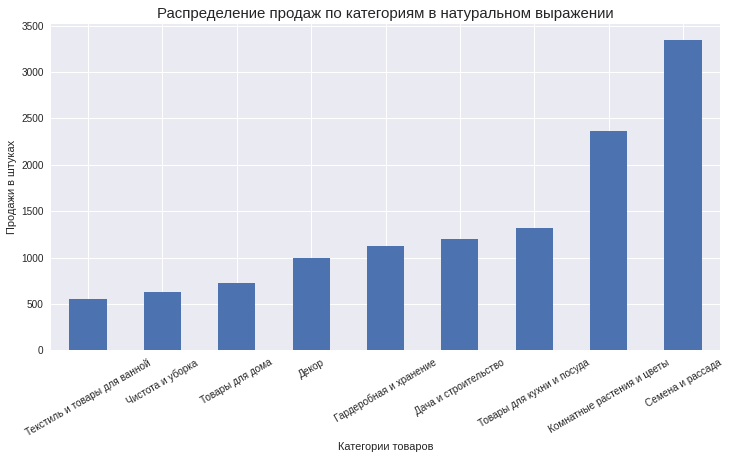

In [42]:
df.groupby('product_group').agg({'quantity': 'sum'}).sort_values(by='quantity').plot(kind='bar', figsize=(12, 6), legend=False,
                            xlabel='Категории товаров', ylabel='Продажи в штуках')
plt.title('Распределение продаж по категориям в натуральном выражении', fontsize=15)
plt.xticks(rotation = 30)
plt.show()

Явно выделяются высокими продажами две схожие категории - семена и рассада, а также комнатные растения и цветы. Хуже всего продаются товары для ванной и текстиль. Остальные категории показывают примерно двухкратный разброс относительно друг-друга.
Дальше изучим товарные категории более подробно и посмотрим как распределяются продажи магазина по выделенным категориям.

#### Изучение распределения продаж по товарным категориям

Построим столбчатую гистограмму на которой будут отображены суммарные продажи по каждой категории и линия средних продаж по всем категориям.

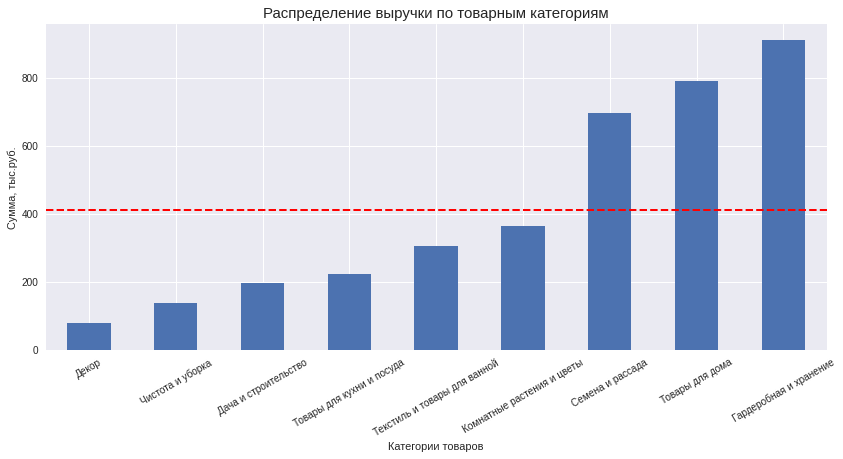

In [43]:
(df.groupby('product_group').agg({'total': 'sum'}).sort_values(by='total')/1000).plot(kind='bar', figsize=(14, 6), legend=False)
plt.title('Распределение выручки по товарным категориям', fontsize=15)
plt.xlabel('Категории товаров')
plt.xticks(rotation = 30)
plt.axhline(y=(df.groupby('product_group').agg({'total': 'sum'}).mean()/1000).values[0], color='r', linestyle='--', linewidth=2)
plt.ylabel('Сумма, тыс.руб.')
plt.show()

Линию средних продаж пересекают следующие категории: семена и рассада, товары для дома, гардеробная и хранение. Очевидным аутсайдером является декор. Для полноты картины дополним данные о суммарной выручке информацией о средней цене товара в категории, а также о продажах в единицах товара.

In [44]:
df.groupby('product_group').agg({'total': 'sum', 'price': 'mean', 'quantity': 'sum'}).round(1).sort_values(by='total', ascending=False)

,total,price,quantity
product_group,,,
Гардеробная и хранение,912779.2,1542.9,1124
Товары для дома,792248.7,1339.7,730
Семена и рассада,698532.0,281.6,3348
Комнатные растения и цветы,364621.3,182.0,2369
Текстиль и товары для ванной,306940.0,783.0,549
Товары для кухни и посуда,223512.0,369.0,1321
Дача и строительство,199027.3,698.5,1201
Чистота и уборка,139421.5,556.5,630
Декор,79570.3,187.1,991


Категории товары для дома и гардеробная и хранение заняли свое место благодаря одновременной наибольшей средней цене и досточно высокими продажами. Самые продаваемые категории - семена и рассада и комнатные растерия и цветы, находящиеся на третьем и четвертом месте соответственно, компенсируют высокие продажи маленькой средней ценой (комнатные растения и цветы обладают минимальным показателем среди всех категорий). Реже всего покупают товары для клининга.

После выделения и первичной оценки полученных товарных групп можно перейти к сегментации клиентов.

###  Формирование профилей клиентов

Для сегментирования клиентов создадим таблицу `customers_profiles` с их профилями - набором признаков, характеризующих каждого клиента. В качестве таких признаков мы будем использовать следующие метрики:
- количество заказов совершенных покупателем;
- среднее количество купленного товара в заказе;
- средняя цена приобретаемых товаров;
- средний чек.

In [45]:
customers_profiles = df.groupby('customer_id').agg(
    {'order_id': 'nunique', 'total': 'sum', 'price':'mean', 'quantity': 'sum'}).reset_index()
customers_profiles['avg_quantity'] = customers_profiles['quantity'] / customers_profiles['order_id']
customers_profiles['avg_check'] = customers_profiles['total'] / customers_profiles['order_id']
customers_profiles = customers_profiles.drop(['quantity', 'total'], axis=1)
customers_profiles.columns = ['customer_id', 'order_cnt', 'avg_price', 'avg_quantity', 'avg_check']
customers_profiles

,customer_id,order_cnt,avg_price,avg_quantity,avg_check
0,000d6849-084e-4d9f-ac03-37174eaf60c4,1,138.75,4.0,555.0
1,001cee7f-0b29-4716-b202-0042213ab038,1,442.00,1.0,442.0
2,00299f34-5385-4d13-9aea-c80b81658e1b,1,457.00,2.0,914.0
3,002d4d3a-4a59-406b-86ec-c3314357e498,1,1649.00,1.0,1649.0
4,003bbd39-0000-41ff-b7f9-2ddaec152037,1,1162.00,2.0,2324.0
...,...,...,...,...,...
2420,ff601403-b094-4b86-9ac6-264d725b9277,2,869.50,1.0,869.5
2421,ffaeab76-3a8d-49ee-860f-17273b2fc8a2,1,397.00,1.0,397.0
2422,ffb5976a-7a4d-460b-95c4-5ffaba31cb24,1,389.00,1.0,389.0
2423,ffb80538-3fda-4351-8ea9-9d2bec58bb07,1,974.00,1.0,974.0


### Проведение кластеризации клиентов по сформированным ранее профилям

Проведем кластеризацию покупателей магазина. Из таблице профилей сформируем матрицу признаков X, исключив поле с id покупателя. Так как для моделей кластеризации крайне важна стандартизация данных, предварительно проведем её.

In [46]:
X = customers_profiles.drop('customer_id', axis=1)

scaler = StandardScaler()
X_st = scaler.fit_transform(X)

На стандартизованной матрице признаков построим матрицу расстояний функцией linkage() и выведем дендрограмму.

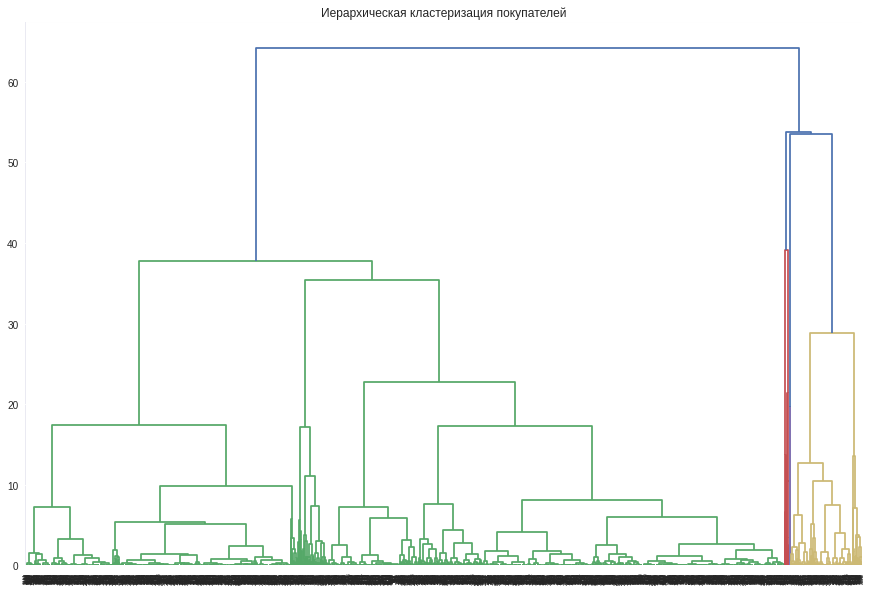

In [47]:
linked = linkage(X_st, method = 'ward')
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация покупателей')
plt.show()

На дендрограмме выделяется 3 кластера, и хотя самый большой охватывает подавляющую часть покупателей, учитывая небольшое количество признаков и размер выборки, не имеет смысла делить клиентов на большее количество сегментов - судя по дендрограме дополнительные кластеры будут слишком малы. Поэтому обучим модель кластеризации на основании алгоритма K-Means с разделением покупателей на 3 кластера.

In [48]:
km = KMeans(n_clusters=3, random_state=0)
labels = km.fit_predict(X_st)
customers_profiles['cluster'] = labels

Посмотрим как модель разбила покупателей на кластеры, а также средние значения признаков для них.

### Характеристика получившихся сегментов покупателей

Выведем на экран процентную долю каждого кластера (сегмента) покупателей, выделенных алгоритмом K-Means. Также сформируем таблицу со средними значениями признаков для каждого кластера.

In [49]:
print(round(customers_profiles['cluster'].value_counts(normalize=True) * 100, 1))
customers_profiles.groupby('cluster').mean().round(2)

1    90.7
0     8.3
2     1.0
Name: cluster, dtype: float64


,order_cnt,avg_price,avg_quantity,avg_check
cluster,,,,
0,1.65,3294.62,1.78,4090.02
1,1.38,482.27,3.57,789.80
2,1.04,203.61,87.92,8993.04


Покупатели разделились на группы крайн неравномерно - выделяется одна оченб большая и две маленькие группы (суммарно чуть больше 9%).

1) Самая большая группа (**кластер 1**) включает в себя более 90% клиентов и характеризуется наименьшим средним чеком - около 800 рублей. Остальные метрики находятся между 0 и 2 кластерами - покупает средние по цене товары в количестве нескольких штук. Базовый кластер.<br>
2) Средняя по числу клиентов (**кластер 0**) группа единично покупает самые дорогие товары, за счет этого средний чек в 5 раз выше базового кластера. Имеет самую высокую возвращаемость (среднее количество заказов на покупателя).<br>
3) Самый маленький сегмент покупателей (**кластер 2**) покупает самые дешевые товары в очень большом количестве (среднее количество товаро в заказе почти 90 штук), за счет этого средний чек заказа в 11 раз выше базового кластера. Практически никогда не возвращаются за повторыми покупками - среднее количество заказов близко к единице.

Однако перед тем, как анализировать взаимосвязь сформированных сегментов покупателей с товарным ассортиментом, необходимо убедиться в корректности полученного разделения на кластеры.

## Формулирование и проверка статистических гипотез

Чтобы понять насколько корректно модель разбила покупателей на сегменты, необходимо проверить это путем проведения статистических тестов. Для этого сформулируем и проверим две статистические гипотезы, и если хотя бы одна из них покажет статистический уровень значимости различия сегментов по метрикам меджду собой, мы признаем сегментацию проведенной корректно. При проверке обеих гипотез будем использовать коррекцию р-значений для множественного теста методом Холма и базовый уровень статистической значимости равный 5%.

Также зададим функцию `distribution_check` для оценки формы распределения имеющихся выборок заданной метрики в разбивке по кластерам для выбора статистического теста.

In [50]:
# Функция принимает на вход название таблицы с необходимыми данными (data), название колонки с признаком по короторому
# строится распределение (attribute) и название колонки содержащей информацию о сегментах/кластерах (cluster_column, по 
# умолчанию 'cluster')
def distribution_check(data, attribute, cluster_column='cluster'):
    cluster_cnt = data[cluster_column].nunique()
    fig_sup, axes = plt.subplots(nrows=math.ceil(cluster_cnt/3), ncols=3, figsize=(17, (4*math.ceil(cluster_cnt/3))))
    plt.suptitle('Распределение метрики {} по кластерам'.format(attribute), fontsize=17)
    axs = axes.ravel()
    for cluster in data[cluster_column].unique():
        if data[data[cluster_column] == cluster][attribute].nunique() >= 20:
            att_bins = 20
        else:
            att_bins = data[data[cluster_column] == cluster][attribute].nunique()
        data[data[cluster_column] == cluster][attribute].plot(
                kind='hist', bins=att_bins, title='{}: {}'.format(cluster_column, cluster), ax=axs[cluster])
    plt.show()

### Проверка гипотезы о значимости разницы средней стоимости заказа между клиентами выделенных сегментов

Начнем с формулирования нулевой и альтернативной гипотез\
**H0 (нулевая гипотеза):** нет значимых различий в средней стоимости заказа (avg_check) между кластерами\
**H1 (двусторонняя альтернативная гипотеза):** есть значимая разница в средней стоимости заказа между кластерами

Далее оценим форму распределения имеющихся выборок с данными о среднем чеке вызвав функцию distribution_check.

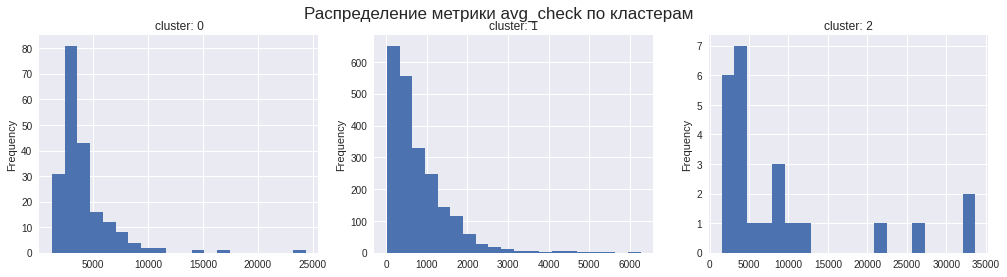

In [51]:
distribution_check(customers_profiles, 'avg_check')

Формы распределения некоторых кластеров далеки от нормального, поэтому для проверки гипотезы используем непараметрический U-критерий Манна-Уитни. <br> Зададим функцию `hypothesis_testing`, которая комбинирует все кластеры на неповторяющиеся пары, внутри каждой проводит тест Манна-Уитни, записывает полученное значение p-value в виде списка во внутреннюю переменную, которая передается функции multipletests, проводящей коррекцию р-значений методом Холма, повторно проверяет скоррекированные р-значения с заданным уровнем alpha и в зависимости от того, проходят ли тест все возможные парные комбинации кластеров, выдает сообщение о итоге проведенного теста.

In [52]:
# Функция принимает на вход название таблицы с необходимыми данными (data), название колонки с признаком по короторому
# проводится статистический тест (attribute), название колонки содержащей информацию о сегментах/кластерах (cluster_column, по 
# умолчанию 'cluster') и критический уровень значимости (alpha, по умолчанию равен 5%)
def hypothesis_testing(data, attribute, cluster_column='cluster', alpha=0.05):
    p_values = []
    for i in itertools.combinations(data[cluster_column].unique(), 2):
        results = stats.mannwhitneyu(data[data[cluster_column] == i[0]][attribute].to_list(),
                                     data[data[cluster_column] == i[1]][attribute].to_list())
        p_values.append(results.pvalue)
    
    score = multipletests(p_values, alpha=alpha, method='holm')[0].sum()
    if score==data[cluster_column].nunique():
        print('Отвергаем нулевую гипотезу, разница статистически значима')
    else:
        print('Не получилось отвергнуть нулевую гипотезу, вывод о различии кластров сделать нельзя')

In [53]:
hypothesis_testing(customers_profiles, 'avg_check')

Отвергаем нулевую гипотезу, разница статистически значима


### Проверка гипотезы о значимости разницы среднего количества товаров в заказе между клиентами выделенных сегментов

**H0 (нулевая гипотеза):** нет значимых различий в среднем количестве товара в заказе (avg_quantity) между кластерами
**H1 (двусторонняя альтернативная гипотеза):** есть значимая разница в среднем количестве товара в заказе между кластерами

Оценим форму распределения выборок с данными о количестве заказов функцией distribution_check.

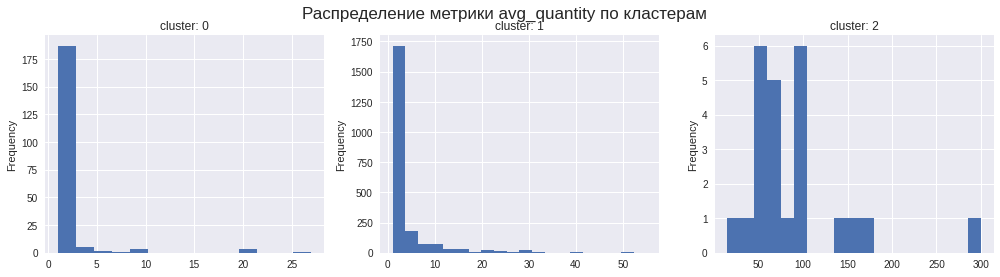

In [54]:
distribution_check(customers_profiles, 'avg_quantity')

Распределения сложно отнести к нормальным, используем U-критерий Манна-Уитни вызвав функцию hypothesis_testing.

In [55]:
hypothesis_testing(customers_profiles, 'avg_quantity')

Отвергаем нулевую гипотезу, разница статистически значима


Кластеризация полученная в результате работы алгоритма K-Means успешно прошла оба статистических теста, которые показали статистически значимую разницу между средней ценой заказа и средним количеством товара в заказе у покупателей в разных кластерах. Теперь можно изучить потребительское поведение покупателей из разных кластеров.

## Профили потребительского поведения клиентов из разных сегментов

Для анализа потребительских предпочтений добавим в основной датафрейм df информацию о принадлежности покупателей совершавших транзакции к определенному сегменту. Также дополним каждую строку полем `is_weekend` с признаком совершалась ли данная покупка в выходной день.

In [56]:
df = df.merge(customers_profiles[['customer_id', 'cluster']], how='left', on='customer_id')
df['is_weekend'] = np.where(df['date'].dt.floor('d').dt.dayofweek.isin([5,6]), 1, 0)

### Кластер 0

В первую очередь оценим распределение покупок и сумм транзакций по товарным группам при помощи горизонтальной столбчатой диаграммы и графика "ящик с усами" соответственно.

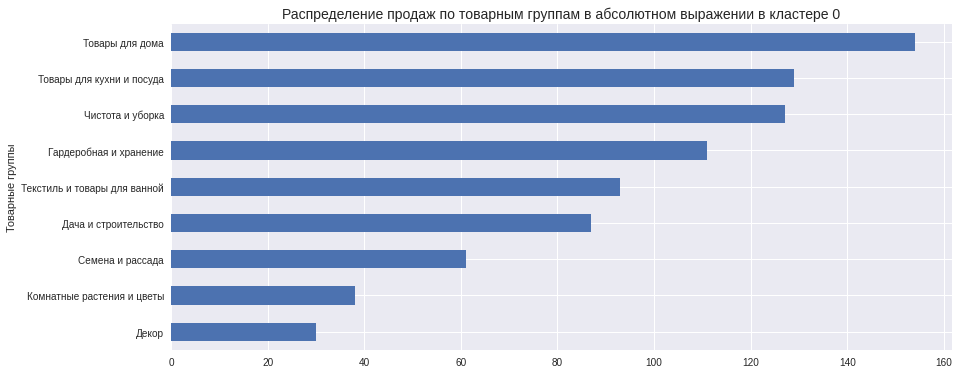

In [57]:
df.query('cluster == 0').groupby('product_group').agg({'quantity': 'sum'}).sort_values(by='quantity'
        ).plot(kind='barh', figsize=(14, 6), legend=False, xlabel='Товарные группы')
plt.title('Распределение продаж по товарным группам в абсолютном выражении в кластере 0', fontsize = 14)
plt.show()

Продажи распределены достаточно равномерно, аномально представленных товарных категорий нет. Больше всего покупают товары для дома, меньше всего декор. Рассада и комнатые растения относятся к аутсайдерам в данном кластере. 

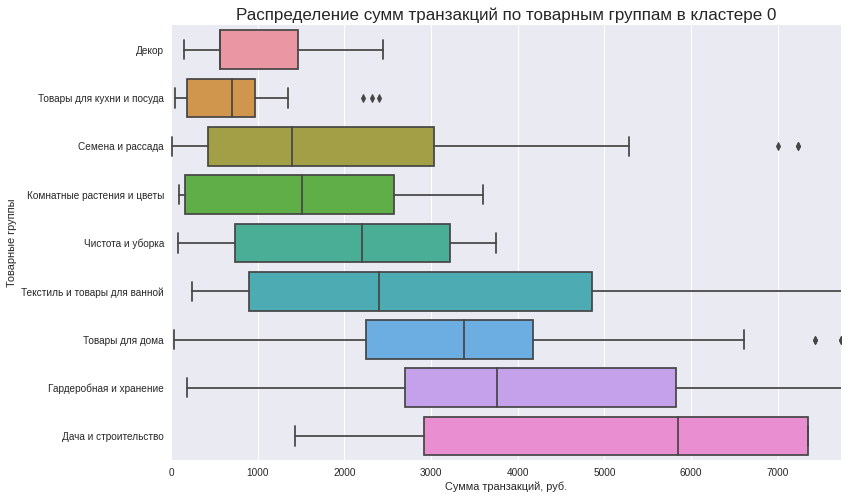

In [58]:
plt.figure(figsize=(12,8))
fig = sns.boxplot(order=df.query('cluster == 0').groupby('product_group').median().sort_values(by='total').index,
    data=df.query('cluster == 0'), x='total', y='product_group').set(
    xlabel='Сумма транзакций, руб.', ylabel='Товарные группы', 
    xlim=([0, np.percentile(df.query('cluster == 0')['total'], 95)]))
ax = plt.gca()
ax.set_title('Распределение сумм транзакций по товарным группам в кластере 0', fontsize=17)
plt.show()

По цене офоромляемых заказов безоговорочно лидирует категория дача и строительство, её медиана превосходит третий квартиль любых других категорий. Что интересно, Усы графика этой категории заказчиваются на третьем квартиле - очень дорогих заказов в этой категории вообще нет. Минимальные суммы собирают декор и товары для кухни с посудой. И если самая никая медиана декора соответствует самым низким продажам в штуках, то крайне небольшой межквартильный размах товаров для кухни компенсируется вторым местом по абсолютным продажам в штуках. Стоит отметить практически полное отсутствие выбросов в этом кластере - товарные предпочтения покупателей из него очень однородны, практически нет товаров с сильно выбивающимися ценами. Теперь посмотрим наблюдается ли сезонность в продажах этого кластера, для этого построим пару графиков, верхний из которых показывает распределение по временной линии общих продаж, а нижний дает разбивку по 5 наиболее продаваемым категориям внутри кластера.

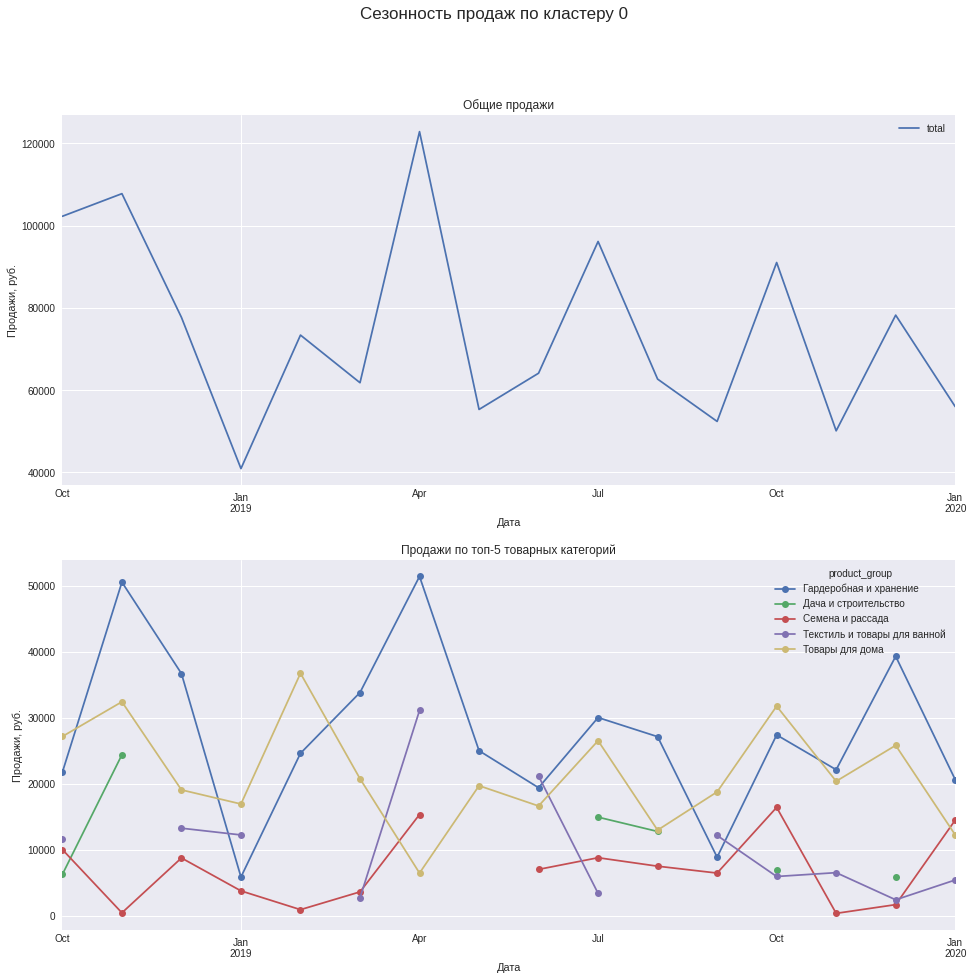

In [59]:
fig_sup, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 15))
axs = axes.ravel()
plt.suptitle('Сезонность продаж по кластеру 0', fontsize=17)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
df.query('cluster == 0').groupby(df['date'].astype('datetime64[M]')).agg({'total': 'sum'}).plot(
    xlabel='Дата', ylabel='Продажи, руб.', title='Общие продажи', ax=axs[0])
df[(df['cluster'] == 0)&
   (df['product_group'].isin(
    df.query('cluster == 0').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).head(5).index.values))
  ].pivot_table(index=df['date'].astype('datetime64[M]'), columns='product_group', values='total', 
    aggfunc='sum').plot(xlabel='Дата', ylabel='Продажи, руб.', style='o-',
    title='Продажи по топ-5 товарных категорий', ax=axs[1])
plt.show()

Выраженная сезонность отсутствует, как в общих продаж внутри кластера, так и по отдельным категориям. Возможно она выражена в разбике на рабочие и выходные дни, проверим.

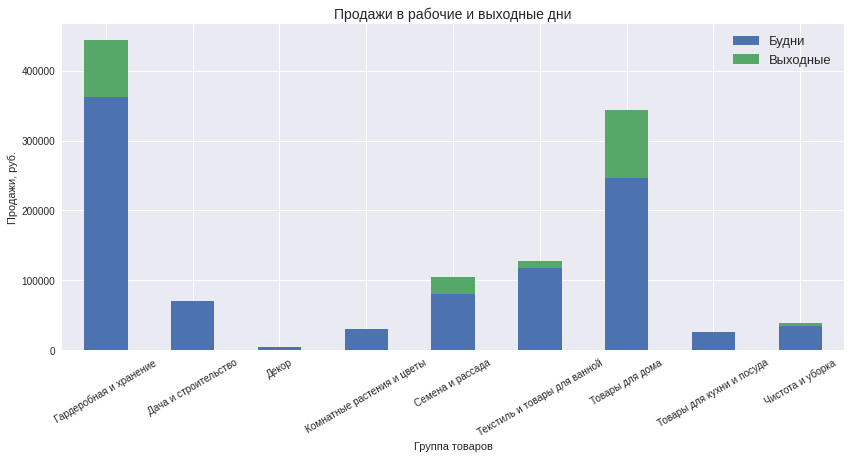

In [60]:
df.query('cluster == 0').pivot_table(index='product_group', columns='is_weekend', values='total', aggfunc='sum').plot(
    kind='bar', xlabel='Группа товаров', ylabel='Продажи, руб.', stacked=True, figsize=(14, 6))
plt.title('Продажи в рабочие и выходные дни', fontsize = 14)
plt.legend(['Будни', 'Выходные'], fontsize=13)
plt.xticks(rotation = 30)
plt.show()

Покупатели из нулевого кластера в основном покупают в будние дни, по большинству товарных групп продажи в выходные гораздо меньше не только в абсолютном, но и в относительном (с учетом количества выходных дней в неделе) выражении.\
Посмотрим на ранжирование товарных категорий по гененируемой кластером выручке и перейдем к следующему кластеру:

In [61]:
df.query('cluster == 0').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).round()

,total
product_group,
Гардеробная и хранение,444188.0
Товары для дома,343955.0
Текстиль и товары для ванной,127736.0
Семена и рассада,105317.0
Дача и строительство,71031.0
Чистота и уборка,38731.0
Комнатные растения и цветы,30069.0
Товары для кухни и посуда,26424.0
Декор,5172.0


### Кластер 1

Осуществим аналогичную последовательность действий в отношении следующего кластера.

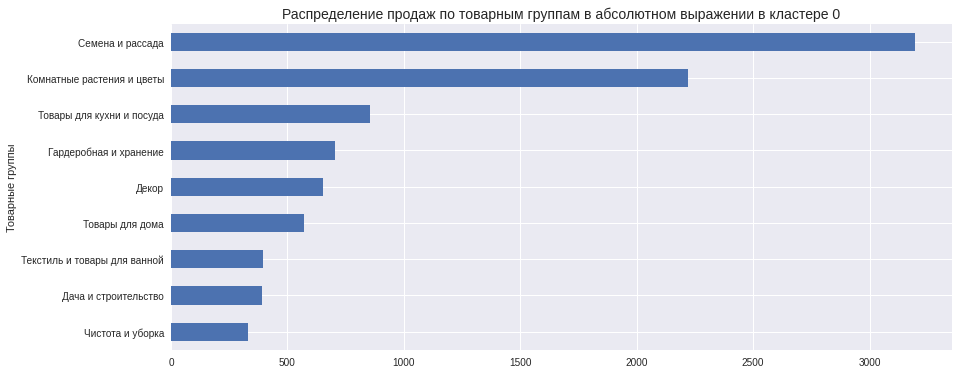

In [62]:
df.query('cluster == 1').groupby('product_group').agg({'quantity': 'sum'}).sort_values(by='quantity'
        ).plot(kind='barh', figsize=(14, 6), legend=False, xlabel='Товарные группы')
plt.title('Распределение продаж по товарным группам в абсолютном выражении в кластере 0', fontsize = 14)
plt.show()

Здесь уже выбивается две явно лидирующие категории - семена и рассада, а также комнатыне растения и цветы. Остальные группы сильно отстают, но хуже всего покупают товары для уборки. А что с ценами?

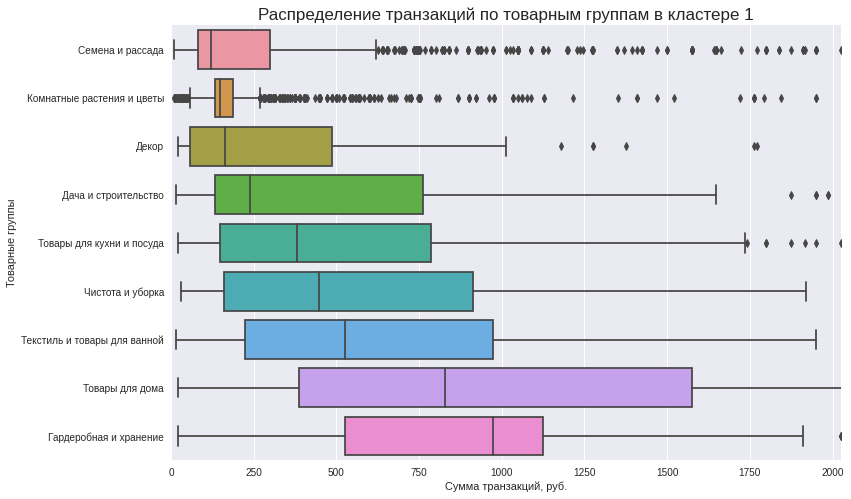

In [63]:
plt.figure(figsize=(12,8))
fig = sns.boxplot(order=df.query('cluster == 1').groupby('product_group').median().sort_values(by='total').index,
    data=df.query('cluster == 1'), x='total', y='product_group').set(
    xlabel='Сумма транзакций, руб.', ylabel='Товарные группы', 
    xlim=([0, np.percentile(df.query('cluster == 1')['total'], 97)]))
ax = plt.gca()
ax.set_title('Распределение транзакций по товарным группам в кластере 1', fontsize=17)
plt.show()

Лидируют категории хранение и товары для дома, медиана первой превосходит третий квартиль всех других категорий. Однако интереснее товаров для хранения смотрятся товары для дома - хотя у них и немного меньше медиана, зато сильно больше третий квартиль, а диапазон нормальных значений выходит за границу оси X, ограниченной 97% перцентилем по кластеру. Очень много выбросов у семян и комнатных растений. При этом интересно выглядят комнатные растения - в категории крайне узкий и низкий межквартильный размах и диапазон нормальных значений, фактически это единственная категория, у которой выделяются выбросы в нижней зоне. Перейдем к сезонности.

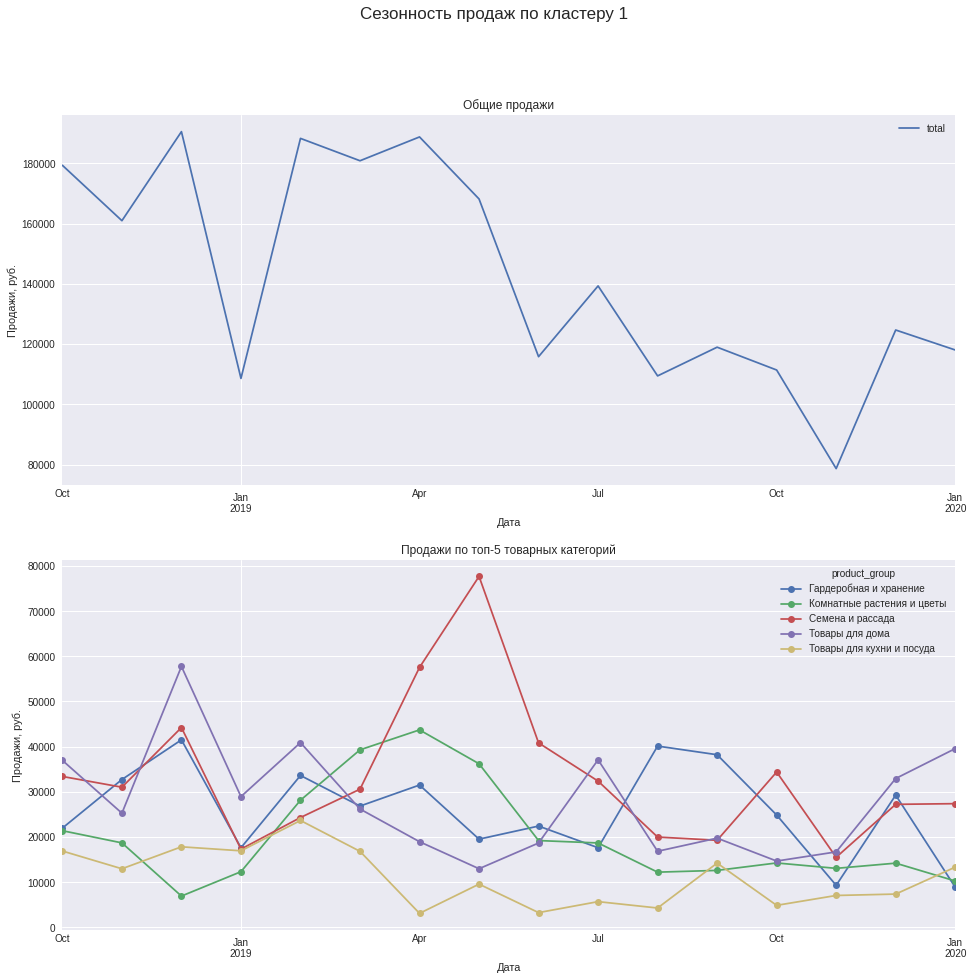

In [64]:
fig_sup, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 15))
axs = axes.ravel()
plt.suptitle('Сезонность продаж по кластеру 1', fontsize=17)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
df.query('cluster == 1').groupby(df['date'].astype('datetime64[M]')).agg({'total': 'sum'}).plot(
    xlabel='Дата', ylabel='Продажи, руб.', title='Общие продажи', ax=axs[0])
df[(df['cluster'] == 1)&
   (df['product_group'].isin(
    df.query('cluster == 1').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).head(5).index.values))
  ].pivot_table(index=df['date'].astype('datetime64[M]'), columns='product_group', values='total', 
    aggfunc='sum').plot(xlabel='Дата', ylabel='Продажи, руб.', style='o-',
    title='Продажи по топ-5 товарных категорий', ax=axs[1])
plt.show()

Можно выделить рост общих продаж начиная с января по апрель, после которого начинается длительный спад. которому предшествует и после которого начинается ощутимый спад. Очень похожую динамику имеет категория комнатные растения и цветы. Очевидную сезонность имеют продажи, что логично, семян и рассады - продажи начинают резко расти в марте, достигают пика в мае, после чего очень быстро падают. Прочие категории ярко выраженной сезонности не демонстрируют. Дополнительно посмотрим на распределение продаж по категориям в разбивке на будни и выходные дни.

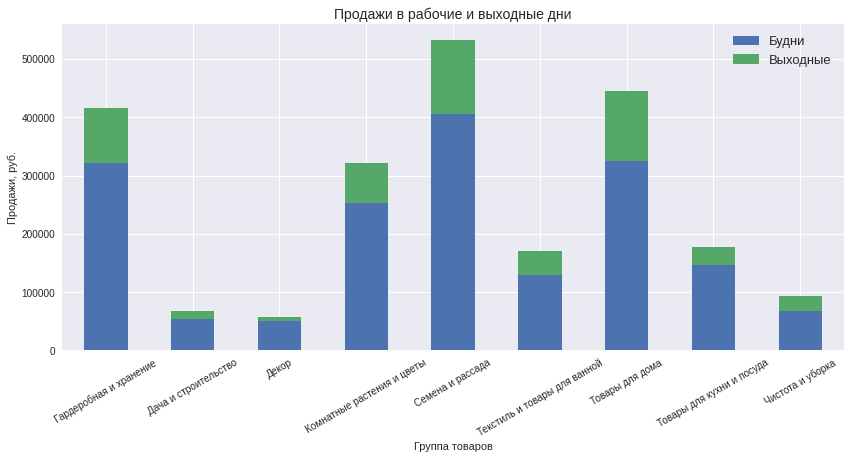

In [65]:
df.query('cluster == 1').pivot_table(index='product_group', columns='is_weekend', values='total', aggfunc='sum').plot(
    kind='bar', xlabel='Группа товаров', ylabel='Продажи, руб.', stacked=True, figsize=(14, 6))
plt.title('Продажи в рабочие и выходные дни', fontsize = 14)
plt.legend(['Будни', 'Выходные'], fontsize=13)
plt.xticks(rotation = 30)
plt.show()

Хотя количество продаж в субботу и воскресенье явно выше предыдущего кластера, в выходные все равно покупают сильно меньше, чем в будни и говорить о каких-либо распродажах выходного дня явно не приходится.

Ранжирование товарных категорий по гененируемой кластером выручке:

In [66]:
df.query('cluster == 1').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).round()

,total
product_group,
Семена и рассада,533115.0
Товары для дома,444224.0
Гардеробная и хранение,416066.0
Комнатные растения и цветы,321222.0
Товары для кухни и посуда,177866.0
Текстиль и товары для ванной,170873.0
Чистота и уборка,93962.0
Дача и строительство,66783.0
Декор,57468.0


Изучим последний оставшийся кластер

### Кластер 2

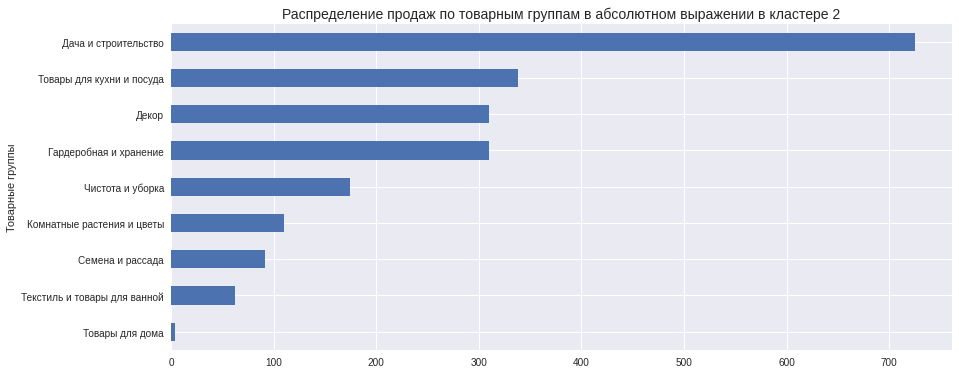

In [67]:
df.query('cluster == 2').groupby('product_group').agg({'quantity': 'sum'}).sort_values(by='quantity'
        ).plot(kind='barh', figsize=(14, 6), legend=False, xlabel='Товарные группы')
plt.title('Распределение продаж по товарным группам в абсолютном выражении в кластере 2', fontsize = 14)
plt.show()

Очевидный лидер продаж - дача и стоительство. За ним очень близко друг к дуругу идут товары для кухни, декор и хранение. После этих групп начинается резкое падение прода, апофеозом которого является группа товаров для дома, с буквально единичными продажами.

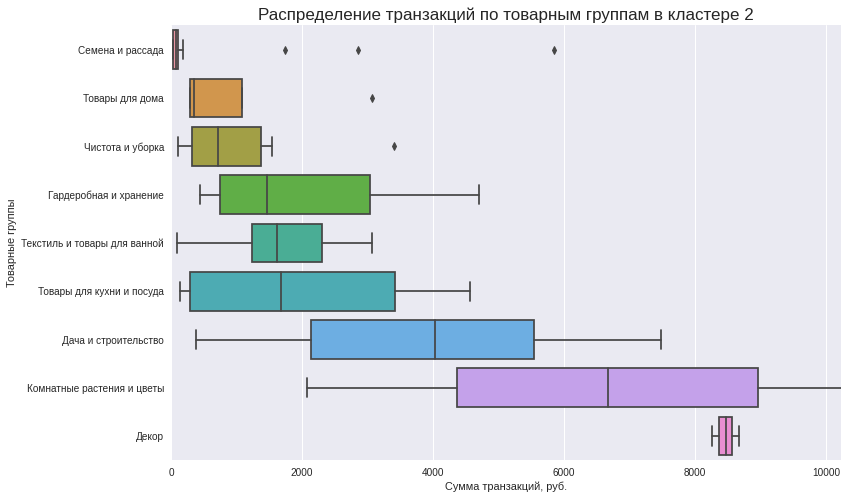

In [68]:
plt.figure(figsize=(12,8))
fig = sns.boxplot(order=df.query('cluster == 2').groupby('product_group').median().sort_values(by='total').index,
    data=df.query('cluster == 2'), x='total', y='product_group').set(
    xlabel='Сумма транзакций, руб.', ylabel='Товарные группы', 
    xlim=([0, np.percentile(df.query('cluster == 2')['total'], 96)]))
ax = plt.gca()
ax.set_title('Распределение транзакций по товарным группам в кластере 2', fontsize=17)
plt.show()

По распределению транзакций кластер 2 выглядит довольно необычно. Первая и последняя по суммам транзакций категории выделяются крайне сильно сжатымы диапазонами значений. Самая дешевая категория - семена и рассада, самая дорогая - декор по медиане, а вот по распределению комнатные растения и цветы.

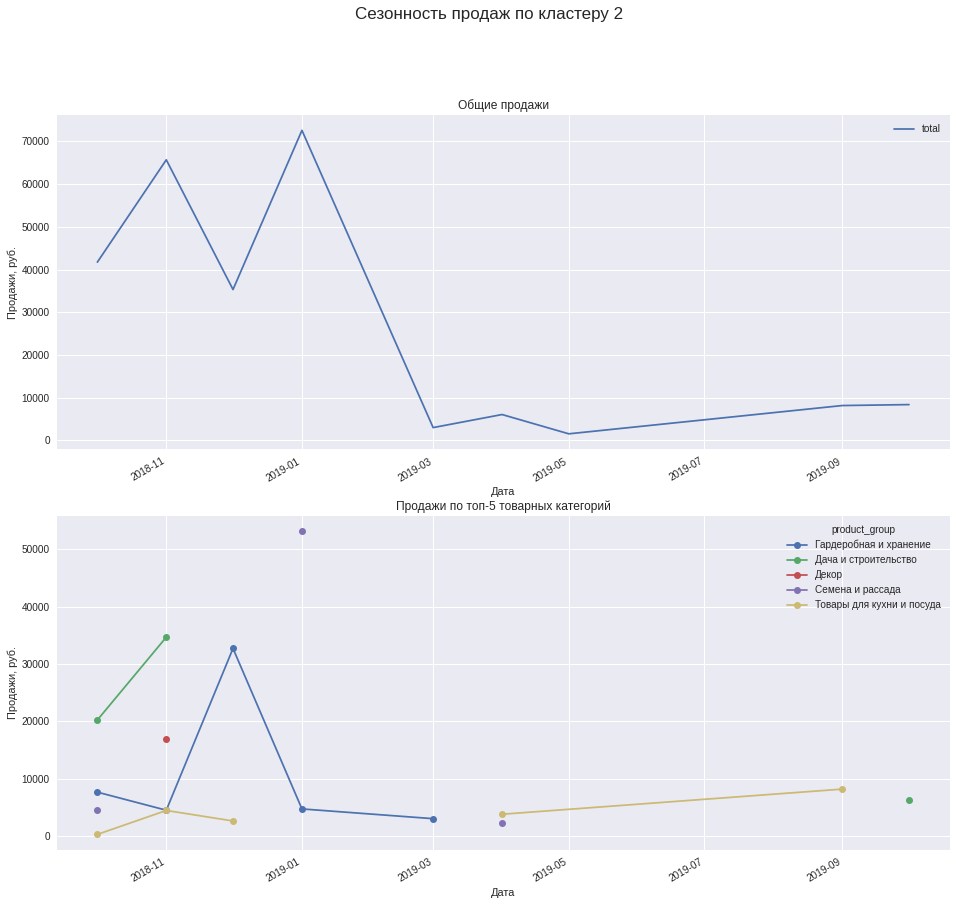

In [69]:
fig_sup, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 15))
axs = axes.ravel()
plt.suptitle('Сезонность продаж по кластеру 2', fontsize=17)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
df.query('cluster == 2').groupby(df['date'].astype('datetime64[M]')).agg({'total': 'sum'}).plot(
    xlabel='Дата', ylabel='Продажи, руб.', title='Общие продажи', ax=axs[0])
df[(df['cluster'] == 2)&
   (df['product_group'].isin(
    df.query('cluster == 2').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).head(5).index.values))
  ].pivot_table(index=df['date'].astype('datetime64[M]'), columns='product_group', values='total', 
    aggfunc='sum').plot(xlabel='Дата', ylabel='Продажи, руб.', style='o-',
    title='Продажи по топ-5 товарных категорий', ax=axs[1])
plt.show()

Из-за очень малого количества клиентов в кластере, а соответствнно и проведенных ими транзакций, построить полноценные графики сезонности не представляется возможным, а соответственно и делать какие-либо выводы о её наличии.

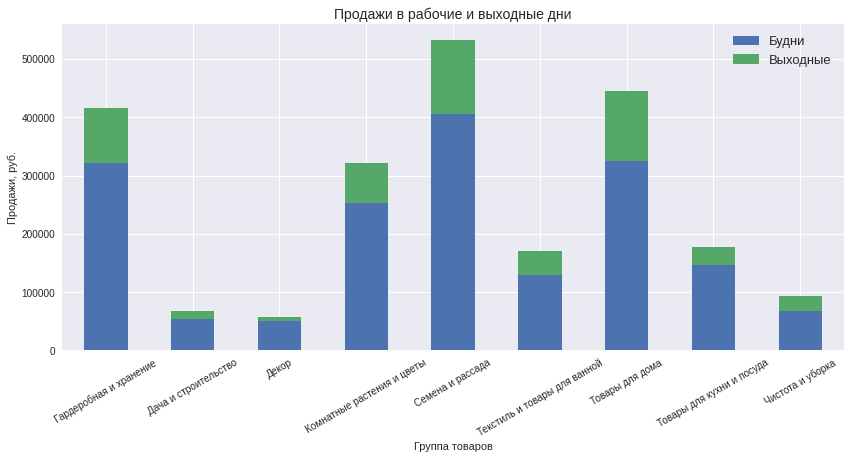

In [70]:
df.query('cluster == 1').pivot_table(index='product_group', columns='is_weekend', values='total', aggfunc='sum').plot(
    kind='bar', xlabel='Группа товаров', ylabel='Продажи, руб.', stacked=True, figsize=(14, 6))
plt.title('Продажи в рабочие и выходные дни', fontsize = 14)
plt.legend(['Будни', 'Выходные'], fontsize=13)
plt.xticks(rotation = 30)
plt.show()

Как и во всех предыдущих кластерах основные продажи приходятся на будние дни. Ранжирование товарных категорий по гененируемой кластером выручке:

In [71]:
df.query('cluster == 2').groupby('product_group').agg({'total': 'sum'}).sort_values(by='total', ascending=False).round()

,total
product_group,
Дача и строительство,61213.0
Семена и рассада,60100.0
Гардеробная и хранение,52525.0
Товары для кухни и посуда,19222.0
Декор,16930.0
Комнатные растения и цветы,13330.0
Текстиль и товары для ванной,8331.0
Чистота и уборка,6729.0
Товары для дома,4069.0


## Общие выводы и рекомендации

В процессе исследования покупатели были поделены на 3 сегмента (кластера), а весь товарный ассортимент разделен на 9 групп. Кластеры не равномерны по своей структуре - количеству покупателей и денежным метрикам, количество же оформляемых заказов очень близко у всех сегментов и находится в диапазоне от 1 до 2 заказов. Перед подробной характеристикой каждого кластера следует описать общие для всех клиентов магазина моменты.
Во-первых, у магазина очень высокий отток и практически нет категории постоянных покупателей, большинство оформляют единичные заказы, после чего возвращаются черезвычайно редко.
Во-вторых, стоит отметить, что все сегменты покупателей делают заказы преимущественно в будние дни: ни в одном кластере нет ни одной категории, внутри которой значительная часть продаж осуществлялась бы в выходные дни. Поэтому нет смысла привязывать рекламные рассылки к выходным.

**Кластер 0**
Хотя и небольшой, но второй по числу сегмент покупателей (немногим более 8%). Штучно покупают наиболее дорогие товары из ассортимента, покупают практически во всех товарных группах, дают высокий средний чек. Самые дорогие заказы - дача и строительство, гардеробная и хранение. Выраженная сезонность отсутствует, как в общих продаж внутри кластера, так и по отдельным категориям. Таким клиентам стоит рассылать рекламу товаров высокой ценовой категории без привязки сезонам - их относительно немного, однако они генерируют значительную часть выручки и наиболее лояльны - совершают повторные заказы чаще всего.
Топ-3 категории по генерируемой выручке:
- Гардеробная и хранение
- Товары для дома
- Текстиль и товары для ванной

**Кластер 1**
Наиболее многочисленный сегмент покупателей - больше 90%. Покупают средние по цене товары, по несколько штук в заказе, дают самый маленький средний чек из всех категорий, возвращаются в магазин редко. Можно назвать условными дачниками: в основном покупают семена и рассаду, а также комнатные растения и цветы, продажи которых имеют сезонность, особенно ярко выраженную у семян и рассады. Среди дорогих товаров в основном приобретают товары для дома, гардеробных и хранения. Им стоит делать рассылку с семенами и рассадой, а также комнатными растениями к началу дачного сезона, с марта по май включительно, добавляя к ней предложения товаров для дома и хранения.
Топ-3 категории по генерируемой выручке:
- Семена и рассада
- Товары для дома
- Гардеробная и хранение

**Кластер 2**
Самый малочисленный сегмент - 1%, что составляет около 25 человек. Условные оптовики, покупают дешевые товары в очень больших количествах, что дает максимальный среди всех категорий чек. Делают единственный заказ и крайне редко возвращаются. В рекламные рассылки стоит включать товары для дачи, декор, семена и рассада, гардеробная и хранение.
Топ-3 категории по генерируемой выручке:
- Дача и строительство
- Семена и рассада
- Гардеробная и хранение